**1) Import Required Libraries**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# For label encoding, splitting dataset and building model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**2) Load the Dataset**

In [23]:
# Load the Social Network Ads dataset
df = pd.read_csv("Social_Network_Ads.csv")

In [24]:
# Display first 5 rows
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


**3) Understand Dataset Structure**

In [25]:
# Dimmensions of dataset
df.shape

(400, 5)

In [26]:
# Datatypes of each column
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

**Description of Columns:**

- User ID → int64
- Gender → object (Categorical)
- Age → int64
- EstimatedSalary → int64
- Purchased → int64 (Target variable)

Purchased:

0 → Not Purchased

1 → Purchased

In [27]:
# Display info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [28]:
# Display statistical summary
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


**4) Handle missing values**

In [29]:
# Check missing values
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

<b>5) Handle Categorical Variable (Gender Encoding)</b>

In [30]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [31]:
# Gender is now encoded into int
df.dtypes

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

In [32]:
# Display updated statistical summary
df.describe()

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,1.569154e+07,0.490000,37.655000,69742.500000,0.357500
std,7.165832e+04,0.500526,10.482877,34096.960282,0.479864
min,1.556669e+07,0.000000,18.000000,15000.000000,0.000000
25%,1.562676e+07,0.000000,29.750000,43000.000000,0.000000
50%,1.569434e+07,0.000000,37.000000,70000.000000,0.000000
75%,1.575036e+07,1.000000,46.000000,88000.000000,1.000000
max,1.581524e+07,1.000000,60.000000,150000.000000,1.000000


<b>6) Boxplot for Outliers</b>

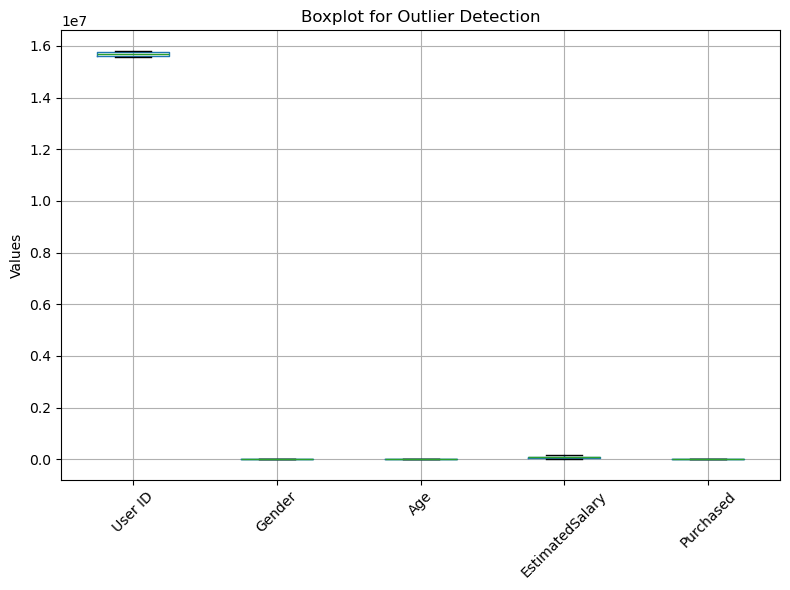

In [33]:
plt.figure(figsize=(8, 6))
df.boxplot()
plt.title('Boxplot for Outlier Detection')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b>Inference: No Outliers present</b>

<b>7) Define Features (X) and Target (y)</b>

X → Independent variables:
- Gender
- Age
- EstimatedSalary

y → Dependent variable:
- Purchased

In [34]:
X = df[['Gender', 'Age', 'EstimatedSalary']]  # Features
y = df['Purchased']                           # Target

<b>9) Split Dataset (Train-Test Split)(80:20)</b>

In [35]:
# Split dataset into training and testing (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

<b>10) Feature Scaling - Standard Scaling</b>

In [36]:
# Apply Standard Scaling

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

<b>11) Train Logistic Regression Model</b>

In [37]:
# Create Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<b>12) Make Predictions</b>

In [38]:
# Predict test data
y_pred = model.predict(X_test)

In [39]:
# Print predictions
print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1]


<b>13) Evaluate Model</b>

<b> - Compute Confusion Matrix</b>

In [40]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56  2]
 [ 5 17]]


<b>- Extract TP, FP, FN, TP values</b>

In [41]:
# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Positive:", TP)
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive: 17
True Negative: 56
False Positive: 2
False Negative: 5


<b>- Performance Metrics</b>

Accuracy = (TP + TN) / Total

Error Rate = (FP + FN) / Total

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

In [42]:
# Total observations
total = TP + TN + FP + FN

# Accuracy
accuracy = (TP + TN) / total

# Error Rate
error_rate = (FP + FN) / total
#OR
#error_rate = 1 - accuracy

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9125
Error Rate: 0.0875
Precision: 0.8947368421052632
Recall: 0.7727272727272727
